In [2]:
import sys

In [3]:
sys.path.append('/content/drive/MyDrive/RAI/Project')

In [ ]:
!git clone https://github.com/ngthvinhrai/NeuralNetworks

Cloning into 'NeuralNetworks'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 84 (delta 32), reused 69 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 17.46 MiB | 10.64 MiB/s, done.
Resolving deltas: 100% (32/32), done.


In [ ]:
from NeuralNetworks.cupy_NeuralNetworks.Model import Sequential
from NeuralNetworks.cupy_NeuralNetworks.Layer import Dense, LSTM, RNN, ModernLSTM, Embedding
from NeuralNetworks.cupy_NeuralNetworks.Activation import Sigmoid, Tanh, Softmax, Linear
from NeuralNetworks.cupy_NeuralNetworks.Loss import CrossEntropy, SpareCrossEntropy
from NeuralNetworks.cupy_NeuralNetworks.Optimizer import GradientDescent, Momentum
from NeuralNetworks.Tokenizer import Tokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import cupy as cp
import pandas as pd
import numpy as np

In [4]:
from NeuralNetworks.Tokenizer import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.activations import softmax
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import cupy as cp
import pandas as pd
import numpy as np

In [5]:
def padding(X, max_length, value):
    if value < 256: b = np.int8
    elif value < 65536: b = np.int16
    new_X = np.zeros((len(X), max_length), dtype=b) + value

    for x, newx in zip(X, new_X):
        newx[(max_length-len(x)):] = np.array([x], dtype=b)

    return new_X

In [6]:
df = pd.read_csv('/content/drive/MyDrive/RAI/Project/Text Classification/data/restaurant_review.csv')

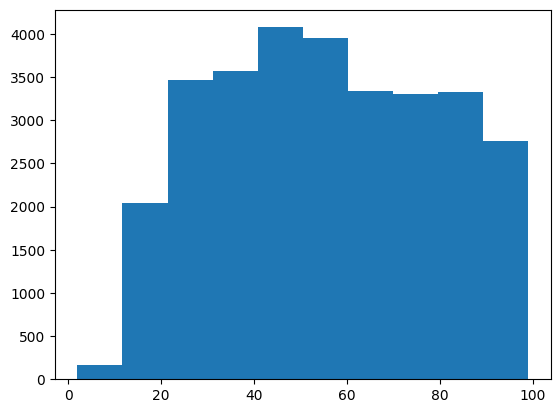

In [ ]:
sentence_length = [len(text.strip().split()) for text in df['text']]
plt.hist(sentence_length)
plt.show()

In [ ]:
max_sentence_length = max(sentence_length)
min_sentence_length = min(sentence_length)
mean_sentence_length = np.mean(sentence_length)
print(f'Max sentence length: {max_sentence_length}')
print(f'Min sentence length: {min_sentence_length}')
print(f'Mean sentence length: {mean_sentence_length}')

Max sentence length: 99
Min sentence length: 2
Mean sentence length: 55.582366666666665


In [7]:
tokenizer = Tokenizer(num_merges=2500)
tokenizer.load('/content/drive/MyDrive/RAI/Project/Text Classification/weights_and_biases/Tokenizer/merge.txt', '/content/drive/MyDrive/RAI/Project/Text Classification/weights_and_biases/Tokenizer/vocab.txt')

In [8]:
token_dataset = []
for text in df['text']: token_dataset.append(tokenizer.encode(text))


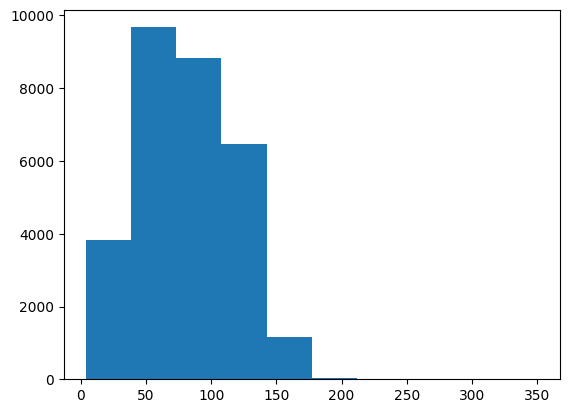

In [ ]:
token_sentence_length = [len(text) for text in token_dataset]
plt.hist(token_sentence_length)
plt.show()

In [ ]:
max_token_sentence_length = max(token_sentence_length)
min_token_sentence_length = min(token_sentence_length)
mean_token_sentence_length = np.mean(token_sentence_length)
print(f'Max sentence length: {max_token_sentence_length}')
print(f'Min sentence length: {min_token_sentence_length}')
print(f'Mean sentence length: {mean_token_sentence_length}')

Max sentence length: 350
Min sentence length: 4
Mean sentence length: 80.9553


In [9]:
token_data = np.load('/content/drive/MyDrive/RAI/Project/Text Classification/data/X.npy')
status_class = np.load('/content/drive/MyDrive/RAI/Project/Text Classification/data/Y.npy')

train_dataset, test_dataset, train_label, test_label = train_test_split(token_data, status_class, test_size=0.4, random_state=42)
test_dataset, val_dataset, test_label, val_label = train_test_split(test_dataset, test_label, test_size=0.5, random_state=42)


In [ ]:
train_dataset.shape

(18000, 350)

In [10]:
train_label = np.eye(3)[train_label.astype(np.int8)]
test_label = np.eye(3)[test_label.astype(np.int8)]
val_label = np.eye(3)[val_label.astype(np.int8)]

In [ ]:
tf_model = Sequential([
  Embedding(input_dim=2757, output_dim=300, input_shape=(350,), trainable=True),
  LSTM(32, return_sequences=False),
  Dense(3, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
tf_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 350, 300)       │       827,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        42,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 869,823 (3.32 MB)

 Trainable params: 869,823 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tf_model.compile(optimizer=SGD(learning_rate=0.03), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
tf_his = tf_model.fit(train_dataset, train_label, batch_size=64, epochs=40, validation_data=(val_dataset, val_label), shuffle=True)

Epoch 1/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.3422 - loss: 1.0985 - val_accuracy: 0.4027 - val_loss: 1.0935
Epoch 2/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.3974 - loss: 1.0924 - val_accuracy: 0.3973 - val_loss: 1.0879
Epoch 3/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4070 - loss: 1.0856 - val_accuracy: 0.4197 - val_loss: 1.0809
Epoch 4/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4064 - loss: 1.0797 - val_accuracy: 0.4218 - val_loss: 1.0742
Epoch 5/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4176 - loss: 1.0749 - val_accuracy: 0.4255 - val_loss: 1.0683
Epoch 6/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4256 - loss: 1.0668 - val_accuracy: 0.4290 - val_loss: 1.0616
Epoch 7/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4395 - loss: 1.0580 - val_accuracy: 0.4535 - val_loss: 1.0301
Epoch 8/40
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4527 - loss: 1.0335 - val_accu

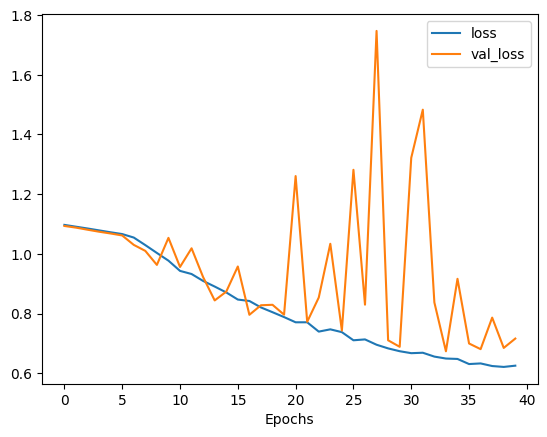

In [ ]:
plt.plot(tf_his.history['loss'], label='loss')
plt.plot(tf_his.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

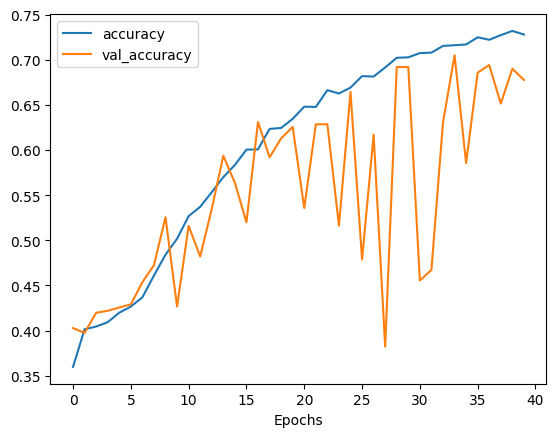

In [ ]:
plt.plot(tf_his.history['accuracy'], label='accuracy')
plt.plot(tf_his.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [ ]:
tf_model.save_weights('/content/drive/MyDrive/Robot and AI/Project/Text Classification/weights_and_biases/weights_32_ndo.weights.h5')

In [12]:
tf_model = Sequential([
  Embedding(input_dim=2757, output_dim=300, input_shape=(350,), trainable=True),
  LSTM(32, return_sequences=False, dropout=0.5),
  Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
tf_model.compile(optimizer=SGD(learning_rate=0.4), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
tf_his = tf_model.fit(train_dataset, train_label, batch_size=64, epochs=20, validation_data=(val_dataset, val_label), shuffle=True)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.3827 - loss: 1.0859 - val_accuracy: 0.3845 - val_loss: 1.1313
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4539 - loss: 1.0416 - val_accuracy: 0.3407 - val_loss: 1.6235
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.4921 - loss: 1.0156 - val_accuracy: 0.4407 - val_loss: 1.0837
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5405 - loss: 0.9361 - val_accuracy: 0.4260 - val_loss: 1.2529
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5715 - loss: 0.8983 - val_accuracy: 0.5412 - val_loss: 0.9402
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6094 - loss: 0.8551 - val_accuracy: 0.5955 - val_loss: 0.8654
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.6133 - loss: 0.8459 - val_accuracy: 0.5820 - val_loss: 0.9745
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6543 - loss: 0.7686 - val_ac

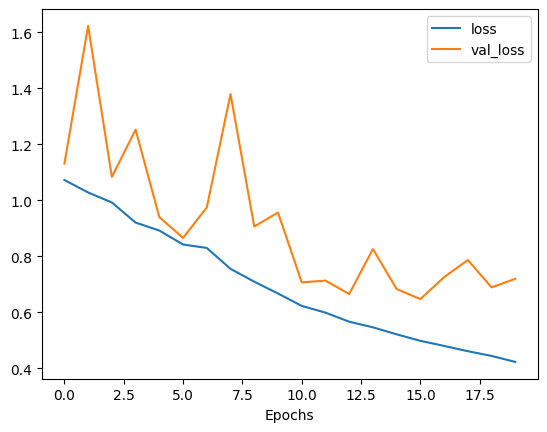

In [ ]:
plt.plot(tf_his.history['loss'], label='loss')
plt.plot(tf_his.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

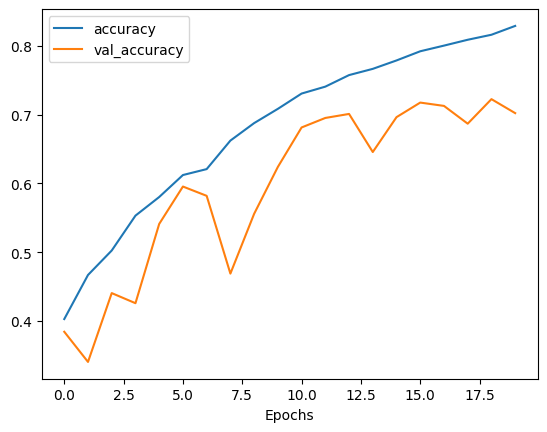

In [ ]:
plt.plot(tf_his.history['accuracy'], label='accuracy')
plt.plot(tf_his.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [ ]:
tf_model.save_weights('/content/drive/MyDrive/RAI/Project/Text Classification/weights_and_biases/weights_32_do05.weights.h5')

In [16]:
tf_model.load_weights('/content/drive/MyDrive/RAI/Project/Text Classification/weights_and_biases/weights_32_do05.weights.h5')

In [17]:
tf_model.evaluate(test_dataset, test_label)

188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6990 - loss: 0.7162


[0.7130797505378723, 0.6973333358764648]

In [18]:
pred = tf_model.predict(test_dataset)

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


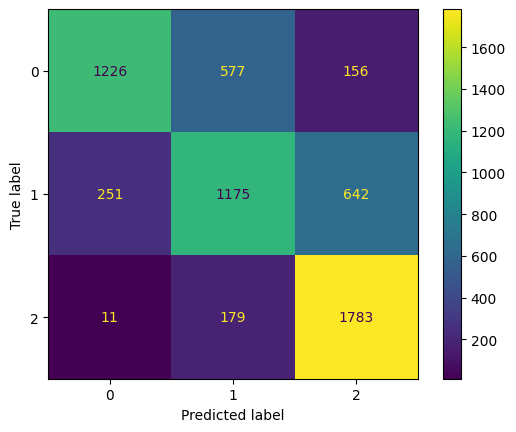

In [19]:
cm = confusion_matrix(np.argmax(test_label, axis=1), np.argmax(pred, axis=1), labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
disp.plot()

In [21]:
print(classification_report(np.argmax(test_label, axis=1), np.argmax(pred, axis=1)))

              precision    recall  f1-score   support

           0       0.82      0.63      0.71      1959
           1       0.61      0.57      0.59      2068
           2       0.69      0.90      0.78      1973

    accuracy                           0.70      6000
   macro avg       0.71      0.70      0.69      6000
weighted avg       0.71      0.70      0.69      6000



In [ ]:
text = "This restaurant offers an inviting ambiance and delicious food. The staff is friendly, and the service is prompt. Highly recommended for a satisfying dining experience!"

In [ ]:
encode_x = tokenizer.encode(text)

In [ ]:
x = padding([encode_x], 350, 2756)

In [ ]:
np.argmax(tf_model.predict(x), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([2])